# Q-learning

In [1]:
import numpy as np
import random

# directions: (dx, dy)
DIRS = [(0, 2), (0, -2), (2, 0), (-2, 0)]

def generate_maze(width, height):
    maze = np.ones((height, width), dtype=int)  # 1 = wall, 0 = path

    def carve(x, y):
        maze[y][x] = 0
        dirs = DIRS[:]
        random.shuffle(dirs)

        for dx, dy in dirs:
            nx, ny = x + dx, y + dy

            if 0 < nx < width-1 and 0 < ny < height-1:
                if maze[ny][nx] == 1:
                    # remove wall between
                    maze[y + dy//2][x + dx//2] = 0
                    carve(nx, ny)

    carve(1, 1)
    return maze

In [10]:
def random_free_cell(maze):
    while True:
        x = np.random.randint(0, maze.shape[1]-1)
        y = np.random.randint(0, maze.shape[0]-1)
        if maze[y][x] == 0:
            return (x, y)


In [12]:
import matplotlib.pyplot as plt

'''
def show_maze(maze):
    plt.imshow(maze, cmap='binary')  # 0=white, 1=black
    plt.xticks([])
    plt.yticks([])
    plt.show()
'''
    
def show_maze(maze, start, goal):
    plt.imshow(maze, cmap='binary')

    plt.scatter(start[0], start[1], c='green', s=100, label='Start')
    plt.scatter(goal[0], goal[1], c='red', s=100, label='Goal')

    plt.legend()
    plt.xticks([])
    plt.yticks([])
    plt.show()


def show_maze_with_agent(maze, agent_pos, start, goal):
    plt.imshow(maze, cmap='binary')

    plt.scatter(start[0], start[1], c='green', s=100, label='Start')
    plt.scatter(goal[0], goal[1], c='red', s=100, label='Goal')
    plt.scatter(agent_pos[0], agent_pos[1], c='blue', s=100, label='Agent')

    plt.legend()
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [69]:
from collections import deque

def bfs_distances(maze, start):
    dist = {start: 0}
    queue = deque([start])

    while queue:
        x, y = queue.popleft()

        for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]:
            nx, ny = x+dx, y+dy
            if (0 <= nx < maze.shape[1] and
                0 <= ny < maze.shape[0] and
                maze[ny][nx] == 0 and
                (nx, ny) not in dist):

                dist[(nx, ny)] = dist[(x, y)] + 1
                queue.append((nx, ny))

    return dist

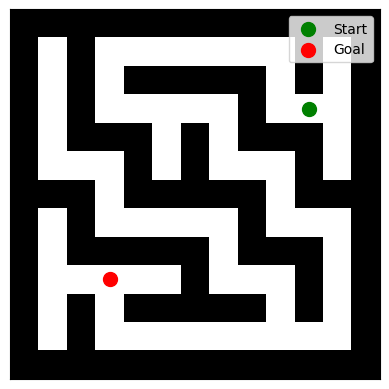

In [79]:
height = 13
width = 13
maze = generate_maze(width, height)
start = random_free_cell(maze)
distances = bfs_distances(maze, start)

# choose one of the farthest nodes
max_dist = max(distances.values())
candidates = [pos for pos, d in distances.items() if d > 0.7 * max_dist]

goal = random.choice(candidates)

show_maze(maze, start, goal)

In [ ]:
from enum import Enum

class Action(Enum):
    UP = 1
    DOWN = 2
    Right = 3
    LEFT = 4

In [ ]:
num_states = width * height
actions = 4